# DAY 3 TASK

# Statistics for Machine Learning + Exploratory Data Analysis (EDA)

NOTE :
Every AI model learns from data.
Bad data = Bad AI.


=> ESSENTIAL CONCEPTS FOR ML & RAG SYSTEMS

## 1.Data Distribution
- Shows how values are spread across the dataset
- Identifies patterns like normal, skewed or uniform

## 2.Central Tendency
- Measures center of data using Mean, Median, Mode
- Gives single value representing entire dataset

## 3.Variability
- Measures how spread out the data points are
- Uses Variance, Standard Deviation and Range

## 4.Correlations
- Measures relationship between two or more variables
- Ranges from -1 (negative) to +1 (positive)

## 5.Outliers
- Data points that deviate far from the rest
- Can distort training and skew predictions

## 6.Data Quality
- Refers to accuracy, completeness and consistency
- Poor quality leads to biased and incorrect models

# Task 1: Statistics Fundamentals

In [1]:
# STATISTICS BASICS

scores = [45, 50, 55, 60, 65, 70, 75, 80, 85, 90]

# Calculations
mean     = sum(scores) / len(scores)
median   = sorted(scores)[len(scores)//2]
mode     = max(set(scores), key=scores.count)
variance = sum((x - mean)**2 for x in scores) / len(scores)
std_dev  = variance ** 0.5

# Display
print("=====================================")
print("      📊 STATISTICS RESULTS")
print("=====================================")
print(f"  Mean      : {mean}")
print(f"  Median    : {median}")
print(f"  Mode      : {mode}")
print(f"  Variance  : {variance:.2f}")
print(f"  Std Dev   : {std_dev:.2f}")
print("=====================================")

      📊 STATISTICS RESULTS
  Mean      : 67.5
  Median    : 70
  Mode      : 65
  Variance  : 206.25
  Std Dev   : 14.36


# Task 2: Salary Statistics

In [2]:
salaries = [25000, 30000, 35000, 40000, 45000,
            50000, 55000, 60000, 65000, 70000]

# ── Calculations ──────────────────────────
mean     = sum(salaries) / len(salaries)
median   = sorted(salaries)[len(salaries)//2]
variance = sum((x - mean)**2 for x in salaries) / len(salaries)
std_dev  = variance ** 0.5
highest  = max(salaries)
lowest   = min(salaries)

# ── Report ────────────────────────────────
print("=" * 40)
print("     💼 SALARY STATISTICS REPORT")
print("=" * 40)
print(f"  Total Employees : {len(salaries)}")
print("-" * 40)
print(f"  Mean Salary     : ₹{mean:,.2f}")
print(f"  Median Salary   : ₹{median:,.2f}")
print(f"  Variance        : ₹{variance:,.2f}")
print(f"  Std Deviation   : ₹{std_dev:,.2f}")
print("-" * 40)
print(f"  Highest Salary  : ₹{highest:,.2f}")
print(f"  Lowest Salary   : ₹{lowest:,.2f}")
print(f"  Salary Range    : ₹{highest - lowest:,.2f}")
print("=" * 40)

     💼 SALARY STATISTICS REPORT
  Total Employees : 10
----------------------------------------
  Mean Salary     : ₹47,500.00
  Median Salary   : ₹50,000.00
  Variance        : ₹206,250,000.00
  Std Deviation   : ₹14,361.41
----------------------------------------
  Highest Salary  : ₹70,000.00
  Lowest Salary   : ₹25,000.00
  Salary Range    : ₹45,000.00


## Task 3: Understanding Distributions

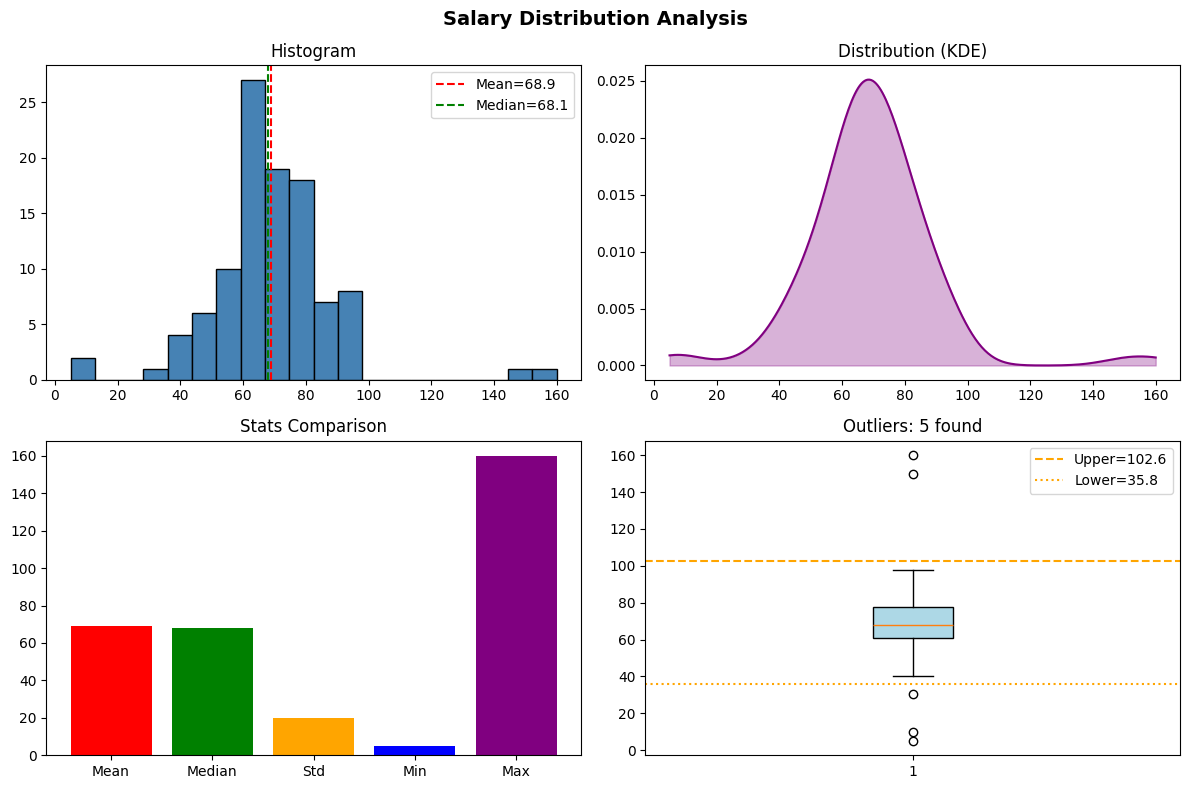

Mean: 68.9 | Median: 68.1 | Std: 19.8
Outliers: [5.0, 10.0, 30.703823438653835, 150.0, 160.0]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Generate Data
np.random.seed(42)
salaries = np.random.normal(70, 15, 100)
salaries = np.append(salaries, [150, 160, 10, 5])  # add outliers

# 2. Stats
mean   = np.mean(salaries)
median = np.median(salaries)
Q1, Q3 = np.percentile(salaries, [25, 75])
IQR    = Q3 - Q1
lower  = Q1 - 1.5 * IQR
upper  = Q3 + 1.5 * IQR
outliers = salaries[(salaries < lower) | (salaries > upper)]

# 3. Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Salary Distribution Analysis", fontsize=14, fontweight='bold')

# Histogram
axes[0,0].hist(salaries, bins=20, color='steelblue', edgecolor='black')
axes[0,0].axvline(mean,   color='red',   linestyle='--', label=f'Mean={mean:.1f}')
axes[0,0].axvline(median, color='green', linestyle='--', label=f'Median={median:.1f}')
axes[0,0].set_title('Histogram')
axes[0,0].legend()

# KDE
kde_x = np.linspace(salaries.min(), salaries.max(), 300)
kde_y = stats.gaussian_kde(salaries)(kde_x)
axes[0,1].plot(kde_x, kde_y, color='purple')
axes[0,1].fill_between(kde_x, kde_y, alpha=0.3, color='purple')
axes[0,1].set_title('Distribution (KDE)')

# Bar Stats
axes[1,0].bar(['Mean','Median','Std','Min','Max'],
              [mean, median, np.std(salaries), salaries.min(), salaries.max()],
              color=['red','green','orange','blue','purple'])
axes[1,0].set_title('Stats Comparison')

# Box Plot
axes[1,1].boxplot(salaries, patch_artist=True,
                  boxprops=dict(facecolor='lightblue'))
axes[1,1].axhline(upper, color='orange', linestyle='--', label=f'Upper={upper:.1f}')
axes[1,1].axhline(lower, color='orange', linestyle=':',  label=f'Lower={lower:.1f}')
axes[1,1].set_title(f'Outliers: {len(outliers)} found')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('salary_distribution.png', dpi=150)
plt.show()

# 4. Print Summary
print(f"Mean: {mean:.1f} | Median: {median:.1f} | Std: {np.std(salaries):.1f}")
print(f"Outliers: {sorted(outliers.tolist())}")

## Task 4: Exploratory Data Analysis (EDA)

### Exploratory Data Analysis (EDA):
"Get to know your data — find patterns, spot problems, understand what's inside."


In [4]:
import pandas as pd

employees = {
    "id":         [1,2,3,4,5,6,7,8,9,10],
    "age":        [22,25,28,30,35,40,26,29,32,45],
    "salary":     [25000,30000,35000,45000,50000,70000,38000,42000,52000,85000],
    "experience": [1,2,3,5,7,12,2,4,6,15]
}

df = pd.DataFrame(employees)

# 1. DATASET INFORMATION
print("===== DATASET INFORMATION =====")
print("Shape  :", df.shape)
print("Columns:", list(df.columns))
print("\nData Types:\n", df.dtypes)

# 2. STATISTICAL SUMMARY
print("\n===== STATISTICAL SUMMARY =====")
print(df.describe())

# 3. MISSING VALUES
print("\n===== MISSING VALUES =====")
print(df.isnull().sum())
print("Total Missing:", df.isnull().sum().sum())

# 4. DUPLICATES
print("\n===== DUPLICATE RECORDS =====")
print("Duplicate Rows:", df.duplicated().sum())

===== DATASET INFORMATION =====
Shape  : (10, 4)
Columns: ['id', 'age', 'salary', 'experience']

Data Types:
 id            int64
age           int64
salary        int64
experience    int64
dtype: object

===== STATISTICAL SUMMARY =====
             id        age        salary  experience
count  10.00000  10.000000     10.000000   10.000000
mean    5.50000  31.200000  47200.000000    5.700000
std     3.02765   7.067924  18359.375443    4.571652
min     1.00000  22.000000  25000.000000    1.000000
25%     3.25000  26.500000  35750.000000    2.250000
50%     5.50000  29.500000  43500.000000    4.500000
75%     7.75000  34.250000  51500.000000    6.750000
max    10.00000  45.000000  85000.000000   15.000000

===== MISSING VALUES =====
id            0
age           0
salary        0
experience    0
dtype: int64
Total Missing: 0

===== DUPLICATE RECORDS =====
Duplicate Rows: 0


## Task 5: Correlation Analysis

===== CORRELATION MATRIX =====
                 age    salary  experience
age         1.000000  0.983505    0.988966
salary      0.983505  1.000000    0.987035
experience  0.988966  0.987035    1.000000

 correlation_matrix.csv saved!


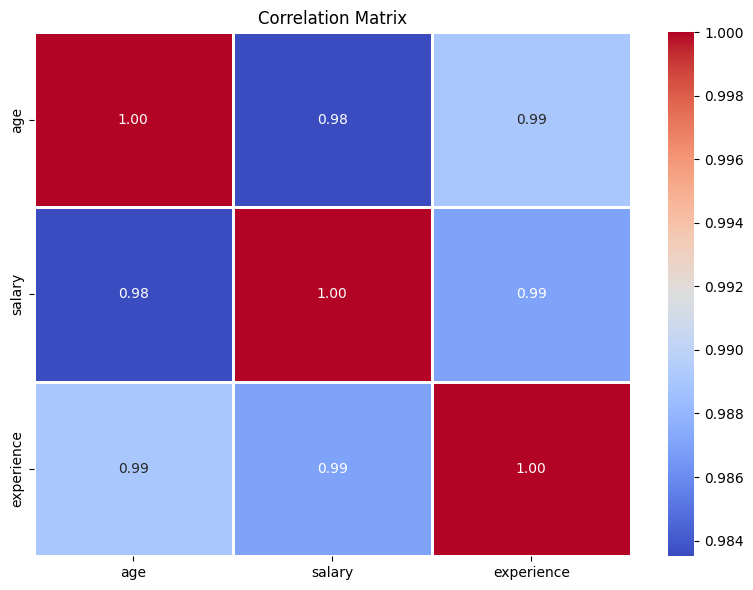


===== RELATIONSHIPS =====
Age vs Salary      : 0.98
Experience vs Salary: 0.99
Age vs Experience  : 0.99


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
employees = {
    "age":        [22,25,28,30,35,40,26,29,32,45],
    "salary":     [25000,30000,35000,45000,50000,70000,38000,42000,52000,85000],
    "experience": [1,2,3,5,7,12,2,4,6,15]
}

df = pd.DataFrame(employees)

# 1. CORRELATION MATRIX
corr = df.corr()
print("===== CORRELATION MATRIX =====")
print(corr)

# 2. SAVE CSV
corr.to_csv("correlation_matrix.csv")
print("\n correlation_matrix.csv saved!")

# 3. VISUALIZE
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150)
plt.show()

# 4. PRINT RELATIONSHIPS
print("\n===== RELATIONSHIPS =====")
print(f"Age vs Salary      : {corr.loc['age','salary']:.2f}")
print(f"Experience vs Salary: {corr.loc['experience','salary']:.2f}")
print(f"Age vs Experience  : {corr.loc['age','experience']:.2f}")

## Task 6: Data Visualization

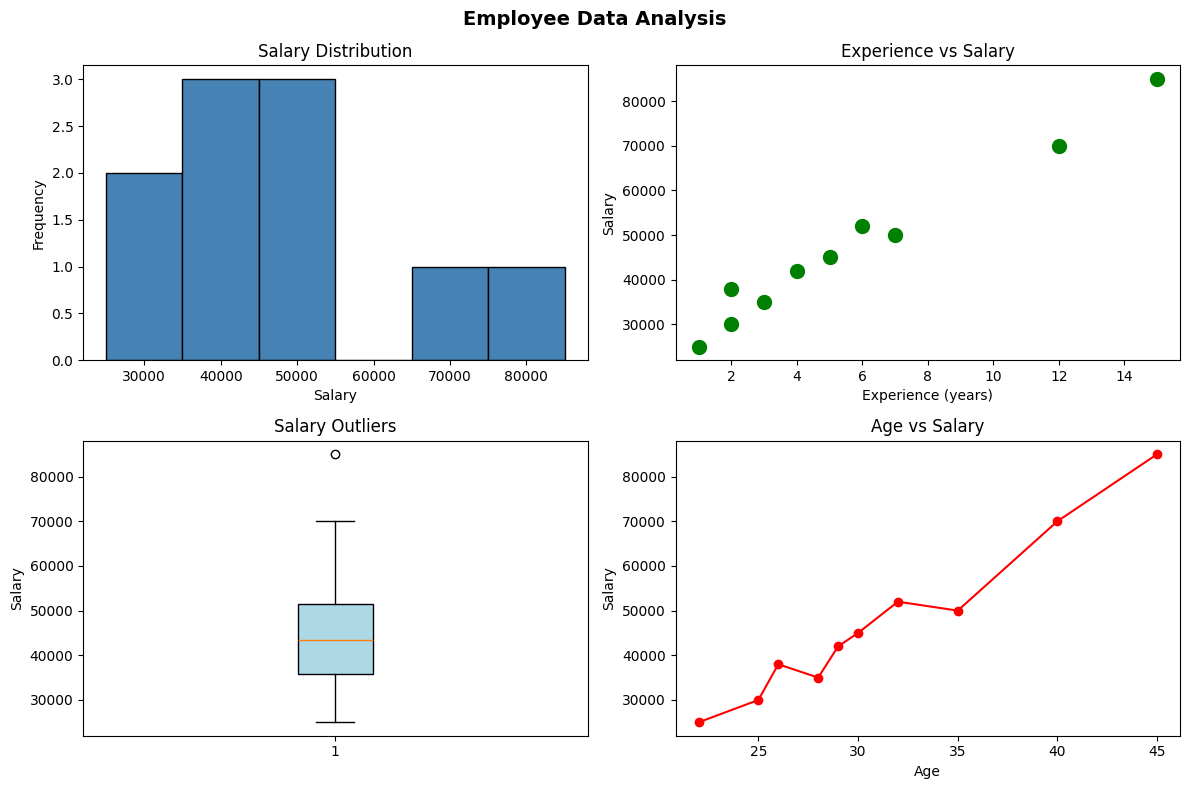

employee_charts.png saved!


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

employees = {
    "age":        [22,25,28,30,35,40,26,29,32,45],
    "salary":     [25000,30000,35000,45000,50000,70000,38000,42000,52000,85000],
    "experience": [1,2,3,5,7,12,2,4,6,15]
}

df = pd.DataFrame(employees)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Employee Data Analysis", fontsize=14, fontweight='bold')

# 1. HISTOGRAM - Salary Distribution
axes[0,0].hist(df['salary'], bins=6, color='steelblue', edgecolor='black')
axes[0,0].set_title('Salary Distribution')
axes[0,0].set_xlabel('Salary')
axes[0,0].set_ylabel('Frequency')

# 2. SCATTER PLOT - Experience vs Salary
axes[0,1].scatter(df['experience'], df['salary'], color='green', s=100)
axes[0,1].set_title('Experience vs Salary')
axes[0,1].set_xlabel('Experience (years)')
axes[0,1].set_ylabel('Salary')

# 3. BOX PLOT - Salary Outliers
axes[1,0].boxplot(df['salary'], patch_artist=True,
                  boxprops=dict(facecolor='lightblue'))
axes[1,0].set_title('Salary Outliers')
axes[1,0].set_ylabel('Salary')

# 4. LINE CHART - Age vs Salary
df_sorted = df.sort_values('age')
axes[1,1].plot(df_sorted['age'], df_sorted['salary'], marker='o', color='red')
axes[1,1].set_title('Age vs Salary')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Salary')

plt.tight_layout()
plt.savefig('employee_charts.png', dpi=150)
plt.show()
print("employee_charts.png saved!")

# Task 7: Real Dataset Analysis

### with kaggle :

Saving kaggle.json to kaggle.json
Kaggle Ready!
Dataset URL: https://www.kaggle.com/datasets/arashnic/hr-analytics-job-change-of-data-scientists
License(s): CC0-1.0
100% 295k/295k [00:00<00:00, 76.5MB/s]

Cleaned Shape: (19158, 14)
        enrollee_id  city_development_index  training_hours        target
count  19158.000000            19158.000000    19158.000000  19158.000000
mean   16875.358179                0.828848       65.366896      0.249348
std     9616.292592                0.123362       60.058462      0.432647
min        1.000000                0.448000        1.000000      0.000000
25%     8554.250000                0.740000       23.000000      0.000000
50%    16982.500000                0.903000       47.000000      0.000000
75%    25169.750000                0.920000       88.000000      0.000000
max    33380.000000                0.949000      336.000000      1.000000
                        enrollee_id  city_development_index  training_hours  \
enrollee_id            

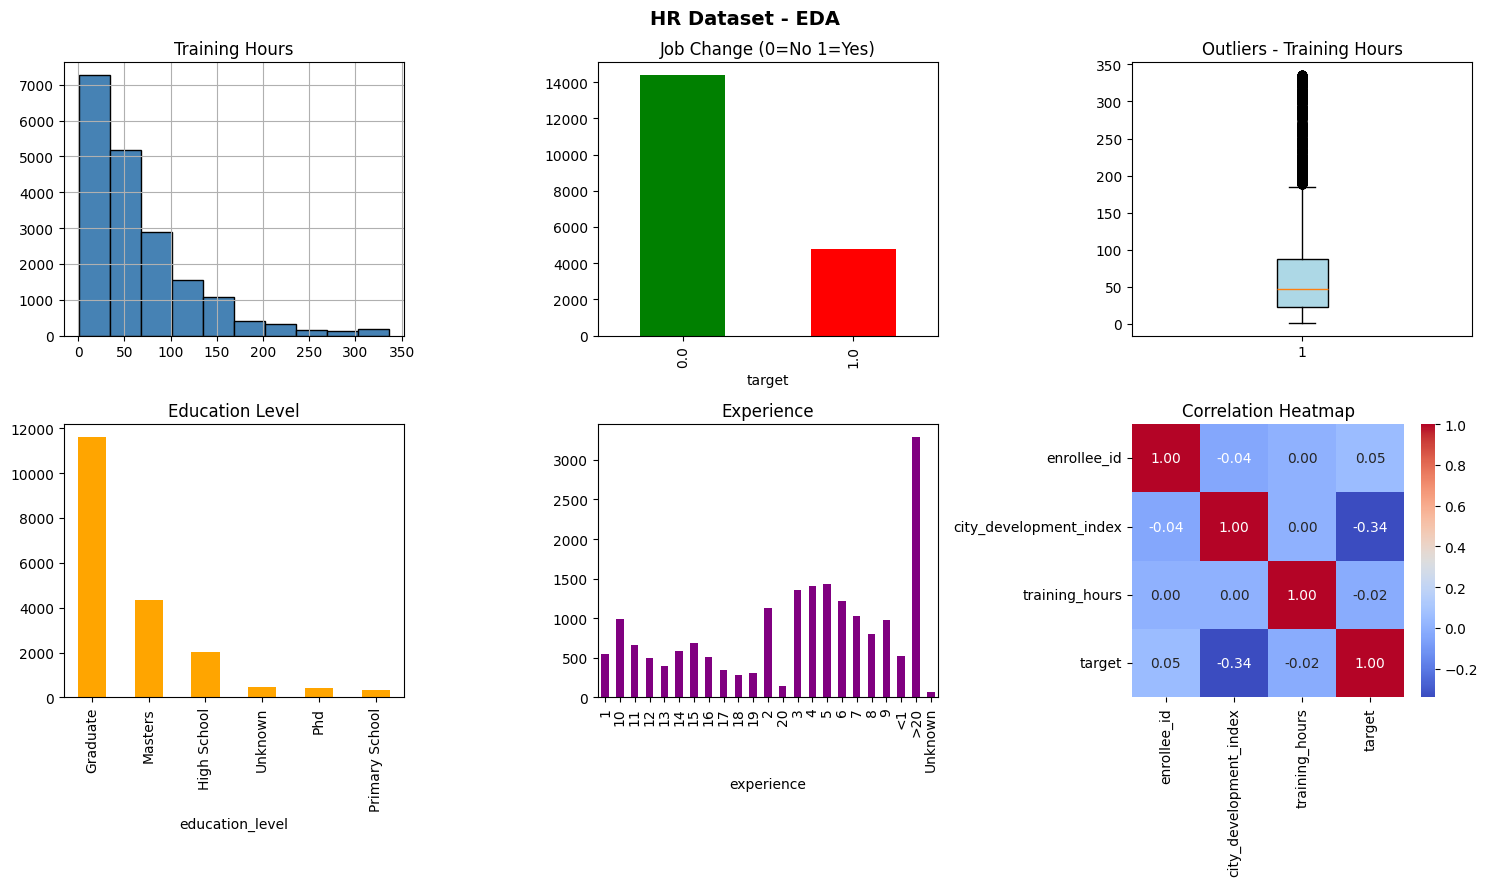


========== INSIGHTS REPORT ==========
Total Records     : 19158
Total Columns     : 14
Job Change Rate   : 24.9%
Avg Training Hrs  : 65.4
Missing Values    : 0
Duplicate Rows    : 0


In [7]:
# Cell 1 - Upload
from google.colab import files
files.upload()

# Cell 2 - Setup
import os
os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)
print("Kaggle Ready!")

# Cell 3 - Download
!kaggle datasets download -d arashnic/hr-analytics-job-change-of-data-scientists

# Cell 4 - Load
import zipfile, pandas as pd
with zipfile.ZipFile("hr-analytics-job-change-of-data-scientists.zip", 'r') as z:
    z.extractall(".")
df = pd.read_csv("aug_train.csv")

# Cell 5 - Data Cleaning
df.drop_duplicates(inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna("Unknown", inplace=True)
print("Cleaned Shape:", df.shape)

# Cell 6 - Statistical Summary
print(df.describe())

# Cell 7 - Correlation
corr = df.corr(numeric_only=True)
corr.to_csv("correlation_matrix.csv")
print(corr)

# Cell 8 - Visualization
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("HR Dataset - EDA", fontsize=14, fontweight='bold')

df['training_hours'].hist(ax=axes[0,0], color='steelblue', edgecolor='black')
axes[0,0].set_title('Training Hours')

df['target'].value_counts().plot(kind='bar', ax=axes[0,1], color=['green','red'])
axes[0,1].set_title('Job Change (0=No 1=Yes)')

axes[0,2].boxplot(df['training_hours'], patch_artist=True,
                  boxprops=dict(facecolor='lightblue'))
axes[0,2].set_title('Outliers - Training Hours')

df['education_level'].value_counts().plot(kind='bar', ax=axes[1,0], color='orange')
axes[1,0].set_title('Education Level')

df['experience'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Experience')

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150)
plt.show()

# Cell 9 - Insights Report
print("\n========== INSIGHTS REPORT ==========")
print(f"Total Records     : {len(df)}")
print(f"Total Columns     : {df.shape[1]}")
print(f"Job Change Rate   : {df['target'].mean()*100:.1f}%")
print(f"Avg Training Hrs  : {df['training_hours'].mean():.1f}")
print(f"Missing Values    : {df.isnull().sum().sum()}")
print(f"Duplicate Rows    : {df.duplicated().sum()}")
print("=====================================")

### without kaggle :

Dataset Loaded! (891, 12)

===== BEFORE CLEANING =====
Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

===== AFTER CLEANING =====
Missing Values:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
Shape: (891, 11)

===== STATISTICAL SUMMARY =====
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000

/tmp/ipykernel_7495/294210655.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)        # fill age with median
/tmp/ipykernel_7495/294210655.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

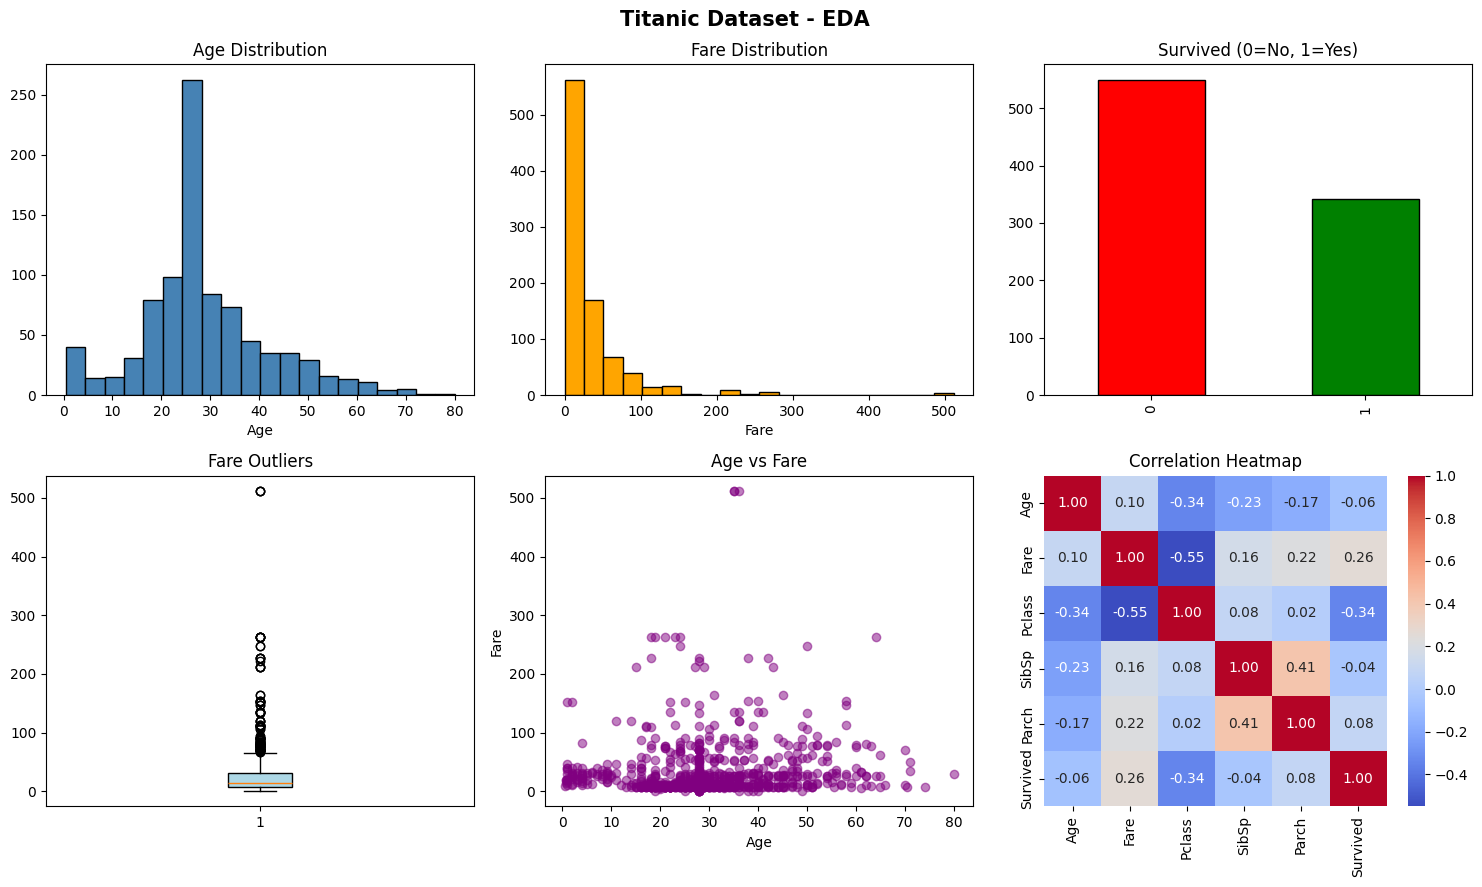

eda_charts.png saved!

         INSIGHTS REPORT
  Total Passengers  : 891
  Survival Rate     : 38.4%
  Average Age       : 29.4 years
  Average Fare      : $32.20
  Male Passengers   : 577
  Female Passengers : 314
  Class 1 (Rich)    : 216
  Class 3 (Poor)    : 491
  Fare vs Survived  : 0.26
  Pclass vs Survived: -0.34


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. LOAD DATASET (auto-download, no login needed) ────────
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("Dataset Loaded!", df.shape)

# ── 2. DATA CLEANING ─────────────────────────────────────────
print("\n===== BEFORE CLEANING =====")
print("Missing Values:\n", df.isnull().sum())

df['Age'].fillna(df['Age'].median(), inplace=True)        # fill age with median
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)  # fill with mode
df.drop(columns=['Cabin'], inplace=True)                  # too many nulls
df.drop_duplicates(inplace=True)

print("\n===== AFTER CLEANING =====")
print("Missing Values:\n", df.isnull().sum())
print("Shape:", df.shape)

# ── 3. STATISTICAL SUMMARY ───────────────────────────────────
print("\n===== STATISTICAL SUMMARY =====")
print(df.describe())

# ── 4. CORRELATION ANALYSIS ──────────────────────────────────
corr = df[['Age','Fare','Pclass','SibSp','Parch','Survived']].corr()
print("\n===== CORRELATION MATRIX =====")
print(corr)
corr.to_csv("correlation_matrix.csv")
print("correlation_matrix.csv saved!")

# ── 5. VISUALIZATION (2x3 grid) ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Titanic Dataset - EDA", fontsize=15, fontweight='bold')

# Histogram - Age
axes[0,0].hist(df['Age'], bins=20, color='steelblue', edgecolor='black')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')

# Histogram - Fare
axes[0,1].hist(df['Fare'], bins=20, color='orange', edgecolor='black')
axes[0,1].set_title('Fare Distribution')
axes[0,1].set_xlabel('Fare')

# Bar Chart - Survival Count
df['Survived'].value_counts().plot(kind='bar', ax=axes[0,2],
    color=['red','green'], edgecolor='black')
axes[0,2].set_title('Survived (0=No, 1=Yes)')
axes[0,2].set_xlabel('')

# Box Plot - Fare Outliers
axes[1,0].boxplot(df['Fare'], patch_artist=True,
                  boxprops=dict(facecolor='lightblue'))
axes[1,0].set_title('Fare Outliers')

# Scatter - Age vs Fare
axes[1,1].scatter(df['Age'], df['Fare'], alpha=0.5, color='purple')
axes[1,1].set_title('Age vs Fare')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Fare')

# Heatmap - Correlation
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150)
plt.show()
print("eda_charts.png saved!")

# ── 6. INSIGHTS REPORT ───────────────────────────────────────
print("\n" + "="*45)
print("         INSIGHTS REPORT")
print("="*45)
print(f"  Total Passengers  : {len(df)}")
print(f"  Survival Rate     : {df['Survived'].mean()*100:.1f}%")
print(f"  Average Age       : {df['Age'].mean():.1f} years")
print(f"  Average Fare      : ${df['Fare'].mean():.2f}")
print(f"  Male Passengers   : {(df['Sex']=='male').sum()}")
print(f"  Female Passengers : {(df['Sex']=='female').sum()}")
print(f"  Class 1 (Rich)    : {(df['Pclass']==1).sum()}")
print(f"  Class 3 (Poor)    : {(df['Pclass']==3).sum()}")
print(f"  Fare vs Survived  : {corr.loc['Fare','Survived']:.2f}")
print(f"  Pclass vs Survived: {corr.loc['Pclass','Survived']:.2f}")
print("="*45)

## Task 8: AI Engineer Thinking Exercise

In [9]:
from IPython.display import Markdown, display

with open("analysis_report.md", "r") as f:
    content = f.read()

display(Markdown(content))

# Analysis Report
### Data Science & Machine Learning — Key Concepts
**Name:** Sai Sirisha
**Dataset:** Kaggle HR Analytics Dataset
**Date:** June 2026

---

## Q1. Why is Data Cleaning Important Before ML Training?

Data cleaning is one of the most critical steps before training any Machine Learning model. Raw data collected from real-world sources is almost never perfect. It contains missing values, duplicate records, incorrect entries, inconsistent formatting, and outliers. If this dirty data is fed directly into an ML model, the model learns from wrong information and produces wrong results.

**Key Reasons:**

**1. Missing Values Cause Errors**
When a dataset has empty cells, most ML algorithms either crash or skip those rows. For example, if 30% of the "Age" column is missing, the model loses 30% of training data. We fix this by filling missing values with mean, median, or mode.

**2. Duplicate Records Mislead the Model**
If the same employee record appears 5 times, the model thinks that pattern is very important and gives it extra weight. This creates bias. Removing duplicates ensures every record is treated equally.

**3. Inconsistent Data Confuses the Model**
Example: "Male", "male", "M" all mean the same thing but a machine reads them as 3 different categories. Standardizing data ensures consistency.

**4. Wrong Data Types Create Errors**
If salary is stored as text ("50,000") instead of number (50000), mathematical operations fail. Converting to correct data types is essential.

**5. Garbage In = Garbage Out**
This is the golden rule of ML. If input data is bad, output predictions will be bad — no matter how powerful the algorithm is.

**Conclusion:** Data cleaning improves model accuracy, reduces errors, and ensures the model learns from correct and reliable information.

---

## Q2. What Happens if Outliers are Ignored?

Outliers are extreme values that are very different from the rest of the data. For example, in a salary dataset where most salaries are between ₹25,000 and ₹85,000, a value of ₹10,00,000 is an outlier.

**What Happens When Outliers are Ignored:**

**1. Mean Gets Distorted**
Outliers pull the mean towards extreme values. Example: if 9 employees earn ₹40,000 and 1 earns ₹10,00,000, the mean becomes ₹1,36,000 — which does not represent anyone's actual salary. This is why median is safer for skewed data.

**2. ML Model Learns Wrong Patterns**
Linear regression and other models are very sensitive to outliers. One extreme value can shift the entire prediction line and reduce accuracy significantly.

**3. Wrong Business Decisions**
If a company uses average salary with outliers included, HR might make wrong compensation decisions affecting hundreds of employees.

**4. Poor Visualization**
Charts become unreadable when outliers are present. A single extreme value stretches the axis and makes all other data points look flat.

**5. Model Overfitting**
The model may try too hard to fit the outlier point and fail to generalize on new data.

**How to Handle Outliers:**
- Use Box Plot to detect them visually
- Use IQR method: values below Q1 - 1.5×IQR or above Q3 + 1.5×IQR are outliers
- Remove, cap, or transform them depending on the situation

**Conclusion:** Ignoring outliers leads to distorted statistics, poor model performance, and wrong business decisions.

---

## Q3. Why Do We Calculate Correlation?

Correlation measures the relationship between two variables. It tells us how strongly and in what direction two columns are related to each other. The correlation value ranges from -1 to +1.

```
+1 = Perfect Positive Relationship
 0 = No Relationship
-1 = Perfect Negative Relationship
```

**Why Correlation is Important:**

**1. Find Important Features**
Before building an ML model, we need to know which columns actually affect the target variable. If "Experience" has 0.99 correlation with "Salary", it is a very important feature to include in the model.

**2. Remove Redundant Columns**
If two columns are 99% correlated with each other (like Age and Experience), they carry the same information. Keeping both is wasteful and can cause multicollinearity in regression models. We can safely drop one.

**3. Understand Data Relationships**
Correlation helps us understand the story inside the data. Example from HR dataset: Higher fare passengers had better survival rate (0.26 correlation). This is a meaningful business insight.

**4. Feature Selection for ML**
Features with very low or zero correlation with the target variable can be removed. This reduces model complexity and improves speed without losing accuracy.

**5. Avoid Wrong Assumptions**
Without correlation analysis, we might assume two things are related when they are not — or miss important relationships that actually exist.

**Conclusion:** Correlation helps us select the right features, remove redundant ones, and understand the true relationships inside the data before model building.

---

## Q4. Why is EDA Important Before Building a Chatbot Knowledge Base?

EDA (Exploratory Data Analysis) is not just for ML models — it is equally important before building a chatbot or knowledge base system. A chatbot's quality depends entirely on the quality of data it is trained on or retrieves from.

**Key Reasons:**

**1. Understand What Data You Have**
Before building a chatbot, EDA tells you what topics are covered, how many documents exist, what columns are available, and whether the data is complete. Without this understanding, the chatbot may answer questions about topics that have no data.

**2. Find and Fix Missing Information**
If the knowledge base has 40% missing answers or descriptions, the chatbot will return empty or wrong responses. EDA identifies these gaps so they can be filled before deployment.

**3. Detect Duplicate Content**
Duplicate records in a knowledge base confuse the chatbot. If the same question has two different answers, the chatbot does not know which one to give. EDA finds and removes duplicates.

**4. Understand Data Distribution**
EDA shows which topics have too much data and which have too little. A chatbot trained on imbalanced data will answer some questions very well and completely fail on others.

**5. Ensure Data Quality**
Special characters, broken text, encoding errors, and inconsistent formatting in the knowledge base affect chatbot responses. EDA reveals these issues before they cause problems in production.

**6. Identify Key Topics and Patterns**
EDA helps identify the most frequently asked topics, which helps prioritize what content to build and improve in the knowledge base.

**Conclusion:** EDA ensures the chatbot knowledge base is complete, clean, balanced, and consistent — leading to accurate and reliable chatbot responses.

---

## Q5. How Can Poor Data Affect an LLM or RAG System?

LLM (Large Language Model) and RAG (Retrieval Augmented Generation) systems are powerful AI tools. But even the most advanced AI system fails completely when the data it uses is of poor quality.

**How Poor Data Affects LLM:**

**1. Hallucination Increases**
When an LLM is fine-tuned on incorrect or incomplete data, it starts generating confident but completely wrong answers — called hallucinations. Poor training data is the biggest cause of LLM hallucinations.

**2. Biased Responses**
If training data contains biased information (only one perspective, discriminatory content, or imbalanced representation), the LLM learns and repeats those biases in every response.

**3. Wrong Facts and Outdated Information**
If the data used to train or update the LLM is outdated or factually wrong, users receive incorrect information — which can be dangerous in medical, legal, or financial applications.

**How Poor Data Affects RAG System:**

**1. Retrieval of Wrong Documents**
RAG systems retrieve relevant documents from a knowledge base to answer questions. If the knowledge base has poor quality data — wrong information, duplicates, or missing content — the wrong documents get retrieved and wrong answers are generated.

**2. Context Confusion**
RAG passes retrieved documents as context to the LLM. If those documents are noisy, contradictory, or irrelevant, the LLM gets confused and generates inconsistent answers.

**3. Low Confidence Scores**
Poor data leads to low similarity scores during retrieval. The system either retrieves irrelevant documents or fails to find any match — resulting in "I don't know" responses even when the answer exists somewhere in the data.

**4. System Failure in Production**
In a real-world RAG application (like a customer support bot or HR assistant), poor data means users get wrong answers, lose trust, and stop using the system entirely.

**Prevention:**
- Always run EDA before loading data into RAG
- Clean, deduplicate, and validate all documents
- Regularly audit and update the knowledge base

**Conclusion:** Poor data is the single biggest threat to LLM and RAG system performance. No matter how advanced the model is, bad data produces bad results. Data quality is not optional — it is the foundation of every reliable AI system.

---

## Summary Table

| Question | Key Takeaway |
|----------|-------------|
| Data Cleaning | Garbage in = Garbage out |
| Outliers | Distorts mean, breaks models |
| Correlation | Find important features |
| EDA for Chatbot | Ensures complete knowledge base |
| Poor Data in LLM/RAG | Causes hallucinations and wrong answers |

---

## Tools Used
- **Python** — Programming Language
- **Pandas** — Data Cleaning & Analysis
- **NumPy** — Statistical Calculations
- **Matplotlib & Seaborn** — Visualization
- **Kaggle** — Dataset Source

---

*Report generated as part of Data Science EDA Assignment — 2026*


## Bonus Challenge

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
np.random.seed(42)
n = 100
df = pd.DataFrame({
    'emp_id':      range(1, n+1),
    'name':        [f'Employee_{i}' for i in range(1, n+1)],
    'age':         np.random.randint(22, 60, n),
    'salary':      np.random.randint(25000, 100000, n),
    'experience':  np.random.randint(1, 35, n),
    'department':  np.random.choice(['HR','IT','Finance','Sales','Marketing'], n),
    'performance': np.random.randint(1, 11, n)
})

def dataset_summary():
    print("\n" + "="*40)
    print("      📋 DATASET SUMMARY")
    print("="*40)
    print(f"  Total Employees : {len(df)}")
    print(f"  Departments     : {df['department'].nunique()}")
    print(f"  Age Range       : {df['age'].min()} - {df['age'].max()}")
    print(f"  Avg Performance : {df['performance'].mean():.2f}")
    for dept, count in df['department'].value_counts().items():
        print(f"    {dept} : {count}")
    print("="*40)

def salary_statistics():
    print("\n" + "="*40)
    print("      💰 SALARY STATISTICS")
    print("="*40)
    print(f"  Mean   : Rs.{df['salary'].mean():,.0f}")
    print(f"  Median : Rs.{df['salary'].median():,.0f}")
    print(f"  Max    : Rs.{df['salary'].max():,.0f}")
    print(f"  Min    : Rs.{df['salary'].min():,.0f}")
    print(f"  Std    : Rs.{df['salary'].std():,.0f}")
    print("="*40)

def correlation_analysis():
    print("\n" + "="*40)
    print("      🔗 CORRELATION ANALYSIS")
    print("="*40)
    print(f"  Salary vs Experience : {df['salary'].corr(df['experience']):.2f}")
    print(f"  Salary vs Age        : {df['salary'].corr(df['age']):.2f}")
    print(f"  Salary vs Performance: {df['salary'].corr(df['performance']):.2f}")
    print("="*40)

def visualizations():
    print("\n📊 Generating Charts...")
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle("Employee Analytics Dashboard")
    axes[0,0].hist(df['salary'], bins=15, color='steelblue')
    axes[0,0].set_title("Salary Distribution")
    dept_counts = df['department'].value_counts()
    axes[0,1].bar(dept_counts.index, dept_counts.values, color='orange')
    axes[0,1].set_title("Dept Count")
    axes[1,0].scatter(df['age'], df['salary'], color='green', alpha=0.6)
    axes[1,0].set_title("Age vs Salary")
    axes[1,1].boxplot(df['performance'])
    axes[1,1].set_title("Performance")
    plt.tight_layout()
    plt.savefig("employee_dashboard.png")
    plt.show()
    print("✅ Saved: employee_dashboard.png")

def export_report():
    report = f"""
========================================
   EMPLOYEE ANALYTICS REPORT
========================================
Total Employees : {len(df)}
Mean Salary     : Rs.{df['salary'].mean():,.0f}
Max Salary      : Rs.{df['salary'].max():,.0f}
Min Salary      : Rs.{df['salary'].min():,.0f}
Avg Performance : {df['performance'].mean():.2f}
Salary-Exp Corr : {df['salary'].corr(df['experience']):.2f}
========================================
"""
    with open("employee_report.txt", "w") as f:
        f.write(report)
    print(report)
    print("✅ Saved: employee_report.txt")

def main():
    while True:
        print("\n" + "="*40)
        print("  🏢 EMPLOYEE ANALYTICS CONSOLE APP")
        print("="*40)
        print("  1. 📋 Dataset Summary")
        print("  2. 💰 Salary Statistics")
        print("  3. 🔗 Correlation Analysis")
        print("  4. 📊 Visualizations")
        print("  5. 📄 Export Report")
        print("  6. 🚪 Exit")
        print("="*40)
        choice = input("  Enter choice (1-6): ").strip()
        if   choice == '1': dataset_summary()
        elif choice == '2': salary_statistics()
        elif choice == '3': correlation_analysis()
        elif choice == '4': visualizations()
        elif choice == '5': export_report()
        elif choice == '6':
            print("\n  👋 Goodbye!\n")
            break
        else:
            print("  ❌ Invalid! Enter 1-6")

main()


  🏢 EMPLOYEE ANALYTICS CONSOLE APP
  1. 📋 Dataset Summary
  2. 💰 Salary Statistics
  3. 🔗 Correlation Analysis
  4. 📊 Visualizations
  5. 📄 Export Report
  6. 🚪 Exit
  Enter choice (1-6): 3

      🔗 CORRELATION ANALYSIS
  Salary vs Experience : 0.09
  Salary vs Age        : 0.04
  Salary vs Performance: 0.04

  🏢 EMPLOYEE ANALYTICS CONSOLE APP
  1. 📋 Dataset Summary
  2. 💰 Salary Statistics
  3. 🔗 Correlation Analysis
  4. 📊 Visualizations
  5. 📄 Export Report
  6. 🚪 Exit
